# RQ1 Robustness Checks: Non-Overlapping Windows And Bootstrap/Null Reference

This notebook is a robustness companion to the main RQ1 centroid-drift notebook. The main RQ1 analysis uses five-year sliding windows with a one-year hop. Because adjacent windows overlap strongly, this notebook checks whether the main modality-level drift findings remain similar under less temporally dependent settings.

The notebook contains three parts:

1. Non-overlapping five-year window drift.
2. Bootstrap confidence intervals for mean modality drift.
3. Optional null reference based on random cross-window genre pairings.

## Load Libraries And Paths

In [21]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from helper_functions import PROCESSED_DIR
except ImportError:
    PROJECT_ROOT = Path.cwd()

    if PROJECT_ROOT.name == "RQ1":
        PROJECT_ROOT = PROJECT_ROOT.parent.parent.parent
    elif PROJECT_ROOT.name == "answer_RQ":
        PROJECT_ROOT = PROJECT_ROOT.parent.parent
    elif PROJECT_ROOT.name == "notebooks":
        PROJECT_ROOT = PROJECT_ROOT.parent

    PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
else:
    PROJECT_ROOT = PROCESSED_DIR.parent.parent

CENTROID_DIR = PROCESSED_DIR / "03_ortools_centroids"
DRIFT_DIR = PROCESSED_DIR / "04_ortools_centroid_drift"
PLOTS_DIR = PROJECT_ROOT / "plots" / "RQ1_robustness"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

print("Project root:", PROJECT_ROOT)
print("Centroid dir:", CENTROID_DIR)
print("Drift dir:", DRIFT_DIR)
print("Plots dir:", PLOTS_DIR)

Project root: /home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis
Centroid dir: /home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/data/processed/03_ortools_centroids
Drift dir: /home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/data/processed/04_ortools_centroid_drift
Plots dir: /home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_robustness


## Analysis Parameters

The non-overlapping robustness check keeps the same five-year window length, but uses a five-year hop. This creates windows such as 1955--1959, 1960--1964, 1965--1969, and so on.

In [22]:
analysis_min_year = 1955
analysis_max_year = 2019
window_size = 5
non_overlapping_hop_size = 5
random_seed = 42
n_bootstrap = 2000
n_null_repetitions = 500

np.random.seed(random_seed)

non_overlapping_window_starts = list(
    range(
        analysis_min_year,
        analysis_max_year - window_size + 2,
        non_overlapping_hop_size,
    )
)

non_overlapping_window_starts[:5], non_overlapping_window_starts[-5:]

([1955, 1960, 1965, 1970, 1975], [1995, 2000, 2005, 2010, 2015])

## Load Existing RQ1 Drift Outputs

The overlapping-window drift output is loaded for comparison with the non-overlapping robustness results.

In [23]:
drift_wpz_neighbors = pd.read_parquet(
    DRIFT_DIR / "rq1_ortools_centroid_drift_wpz_neighbors.parquet"
)

modality_summary = pd.read_csv(
    DRIFT_DIR / "rq1_modality_drift_summary_wpz_neighbors.csv"
)

genre_drift_summary = pd.read_csv(
    DRIFT_DIR / "rq1_genre_drift_summary_wpz_neighbors.csv"
)

modalities = sorted(drift_wpz_neighbors["modality"].unique())

print("Modalities:", modalities)
print("Overlapping drift rows:", len(drift_wpz_neighbors))
drift_wpz_neighbors.head()

Modalities: ['essentia', 'lyrics_tf_idf', 'mfcc', 'musicnn', 'vgg19', 'word2vec']
Overlapping drift rows: 12670


,modality,genre,window_start,window_end,next_window_start,next_window_end,window_gap,n_tracks_t,n_tracks_t1,cosine_distance,euclidean_distance,n_features_used
0,essentia,alternative rock,1979,1983,1980,1984,1,30,44,0.125415,3.081943,1034
1,essentia,alternative rock,1980,1984,1981,1985,1,44,55,0.110539,2.458233,1034
2,essentia,alternative rock,1981,1985,1982,1986,1,55,60,0.056956,1.814056,1034
3,essentia,alternative rock,1982,1986,1983,1987,1,60,79,0.123307,2.622262,1034
4,essentia,alternative rock,1983,1987,1984,1988,1,79,66,0.159518,3.195899,1034


## Helper Functions

In [24]:
def cosine_distance(a: np.ndarray, b: np.ndarray) -> float:
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)

    if norm_a == 0 or norm_b == 0:
        return np.nan

    return 1 - float(np.dot(a, b) / (norm_a * norm_b))


def euclidean_distance(a: np.ndarray, b: np.ndarray) -> float:
    return float(np.linalg.norm(a - b))


def get_feature_columns(frame: pd.DataFrame) -> list[str]:
    metadata_columns = {
        "modality",
        "genre",
        "window_start",
        "window_end",
        "window_label",
        "n_tracks",
        "eligible_centroid",
        "eligible_window",
    }

    feature_columns = [
        column for column in frame.columns
        if column not in metadata_columns
        and pd.api.types.is_numeric_dtype(frame[column])
    ]

    return feature_columns


def load_modality_centroids(modality: str, representation: str = "wpz") -> pd.DataFrame:
    path = CENTROID_DIR / f"{modality}_ortools_centroids_{representation}_windowed.parquet"

    if not path.exists():
        raise FileNotFoundError(path)

    centroids = pd.read_parquet(path)

    if "eligible_centroid" in centroids.columns:
        centroids = centroids[centroids["eligible_centroid"]].copy()
    elif "eligible_window" in centroids.columns:
        centroids = centroids[centroids["eligible_window"]].copy()

    return centroids


def calculate_non_overlapping_drift_for_modality(
    modality: str,
    representation: str = "wpz",
) -> pd.DataFrame:
    centroids = load_modality_centroids(modality, representation=representation)
    centroids = centroids[
        centroids["window_start"].isin(non_overlapping_window_starts)
    ].copy()

    feature_columns = get_feature_columns(centroids)
    rows = []

    for genre, genre_data in centroids.groupby("genre"):
        genre_data = genre_data.sort_values("window_start")
        by_window = {
            int(row["window_start"]): row
            for _, row in genre_data.iterrows()
        }

        for window_start in non_overlapping_window_starts[:-1]:
            next_window_start = window_start + non_overlapping_hop_size

            if window_start not in by_window or next_window_start not in by_window:
                continue

            row_t = by_window[window_start]
            row_t1 = by_window[next_window_start]

            vector_t = row_t[feature_columns].to_numpy(dtype=float)
            vector_t1 = row_t1[feature_columns].to_numpy(dtype=float)

            rows.append({
                "modality": modality,
                "genre": genre,
                "window_start": window_start,
                "next_window_start": next_window_start,
                "window_end": int(row_t.get("window_end", window_start + window_size - 1)),
                "next_window_end": int(row_t1.get("window_end", next_window_start + window_size - 1)),
                "cosine_distance": cosine_distance(vector_t, vector_t1),
                "euclidean_distance": euclidean_distance(vector_t, vector_t1),
                "n_tracks_t": int(row_t.get("n_tracks", np.nan)),
                "n_tracks_t1": int(row_t1.get("n_tracks", np.nan)),
            })

    return pd.DataFrame(rows)

## Non-Overlapping-Window Drift

This section recalculates centroid drift using non-overlapping five-year windows. The goal is to check whether the modality ranking from the main sliding-window analysis remains similar when adjacent comparisons no longer share four out of five years.

In [25]:
non_overlapping_drift_parts = []

for modality in modalities:
    print("Calculating non-overlapping drift for", modality)
    modality_drift = calculate_non_overlapping_drift_for_modality(
        modality=modality,
        representation="wpz",
    )
    non_overlapping_drift_parts.append(modality_drift)

non_overlapping_drift = pd.concat(
    non_overlapping_drift_parts,
    ignore_index=True,
)

non_overlapping_drift.to_parquet(
    DRIFT_DIR / "rq1_ortools_centroid_drift_wpz_non_overlapping.parquet",
    index=False,
)

print(non_overlapping_drift.shape)
non_overlapping_drift.head()

Calculating non-overlapping drift for essentia
Calculating non-overlapping drift for lyrics_tf_idf
Calculating non-overlapping drift for mfcc
Calculating non-overlapping drift for musicnn
Calculating non-overlapping drift for vgg19
Calculating non-overlapping drift for word2vec
(2392, 10)


,modality,genre,window_start,next_window_start,window_end,next_window_end,cosine_distance,euclidean_distance,n_tracks_t,n_tracks_t1
0,essentia,alternative rock,1980,1985,1984,1989,0.739832,7.874203,44,64
1,essentia,alternative rock,1985,1990,1989,1994,0.392183,5.547707,64,222
2,essentia,alternative rock,1990,1995,1994,1999,0.180609,2.643888,222,426
3,essentia,alternative rock,1995,2000,1999,2004,0.099277,1.825954,426,516
4,essentia,alternative rock,2000,2005,2004,2009,0.104901,2.087035,516,741


In [27]:
# Use genre-level means as the analysis units, so genres contribute equally.
non_overlapping_genre_level = (
    non_overlapping_drift
    .groupby(["modality", "genre"], as_index=False)
    .agg(
        genre_mean_cosine_distance=("cosine_distance", "mean"),
        genre_mean_euclidean_distance=("euclidean_distance", "mean"),
        n_transitions=("cosine_distance", "size"),
    )
)

non_overlapping_modality_summary = (
    non_overlapping_genre_level
    .groupby("modality", as_index=False)
    .agg(
        mean_cosine_distance=("genre_mean_cosine_distance", "mean"),
        median_cosine_distance=("genre_mean_cosine_distance", "median"),
        std_cosine_distance=("genre_mean_cosine_distance", "std"),
        mean_euclidean_distance=("genre_mean_euclidean_distance", "mean"),
        n_transitions=("n_transitions", "sum"),
        n_genres=("genre", "nunique"),
    )
    .sort_values("mean_cosine_distance", ascending=False)
)

non_overlapping_modality_summary.to_csv(
    DRIFT_DIR / "rq1_modality_drift_summary_wpz_non_overlapping.csv",
    index=False,
)

non_overlapping_modality_summary

,modality,mean_cosine_distance,median_cosine_distance,std_cosine_distance,mean_euclidean_distance,n_transitions,n_genres
4,vgg19,0.515918,0.526730,0.155086,19.214653,382,50
1,lyrics_tf_idf,0.425376,0.444329,0.130429,5.262631,402,50
0,essentia,0.217768,0.189549,0.104885,5.570055,402,50
5,word2vec,0.185899,0.185997,0.092839,3.200569,402,50
2,mfcc,0.111237,0.099000,0.059079,1.977197,402,50
3,musicnn,0.054685,0.049769,0.031090,1.499759,402,50


## Compare Overlapping And Non-Overlapping Modality Rankings

In [28]:
overlapping_genre_level = (
    drift_wpz_neighbors
    .groupby(["modality", "genre"], as_index=False)
    .agg(
        genre_mean_cosine_distance=("cosine_distance", "mean"),
        n_transitions=("cosine_distance", "size"),
    )
)

overlapping_summary_for_comparison = (
    overlapping_genre_level
    .groupby("modality", as_index=False)
    .agg(
        overlapping_mean_cosine_distance=("genre_mean_cosine_distance", "mean"),
        overlapping_n_transitions=("n_transitions", "sum"),
        overlapping_n_genres=("genre", "nunique"),
    )
)

non_overlapping_summary_for_comparison = (
    non_overlapping_genre_level
    .groupby("modality", as_index=False)
    .agg(
        non_overlapping_mean_cosine_distance=("genre_mean_cosine_distance", "mean"),
        non_overlapping_n_transitions=("n_transitions", "sum"),
        non_overlapping_n_genres=("genre", "nunique"),
    )
)

window_robustness_comparison = overlapping_summary_for_comparison.merge(
    non_overlapping_summary_for_comparison,
    on="modality",
    how="inner",
)

window_robustness_comparison["overlapping_rank"] = (
    window_robustness_comparison["overlapping_mean_cosine_distance"]
    .rank(ascending=False, method="min")
    .astype(int)
)

window_robustness_comparison["non_overlapping_rank"] = (
    window_robustness_comparison["non_overlapping_mean_cosine_distance"]
    .rank(ascending=False, method="min")
    .astype(int)
)

window_robustness_comparison["rank_change"] = (
    window_robustness_comparison["non_overlapping_rank"]
    - window_robustness_comparison["overlapping_rank"]
)

window_robustness_comparison.sort_values("overlapping_rank")

,modality,overlapping_mean_cosine_distance,overlapping_n_transitions,overlapping_n_genres,non_overlapping_mean_cosine_distance,non_overlapping_n_transitions,non_overlapping_n_genres,overlapping_rank,non_overlapping_rank,rank_change
1,lyrics_tf_idf,0.138907,2126,50,0.425376,402,50,1,2,1
4,vgg19,0.106083,2040,50,0.515918,382,50,2,1,-1
5,word2vec,0.063449,2126,50,0.185899,402,50,3,4,1
2,mfcc,0.055587,2126,50,0.111237,402,50,4,5,1
0,essentia,0.054251,2126,50,0.217768,402,50,5,3,-2
3,musicnn,0.025754,2126,50,0.054685,402,50,6,6,0


/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_robustness/rq1_overlapping_vs_non_overlapping_drift.png


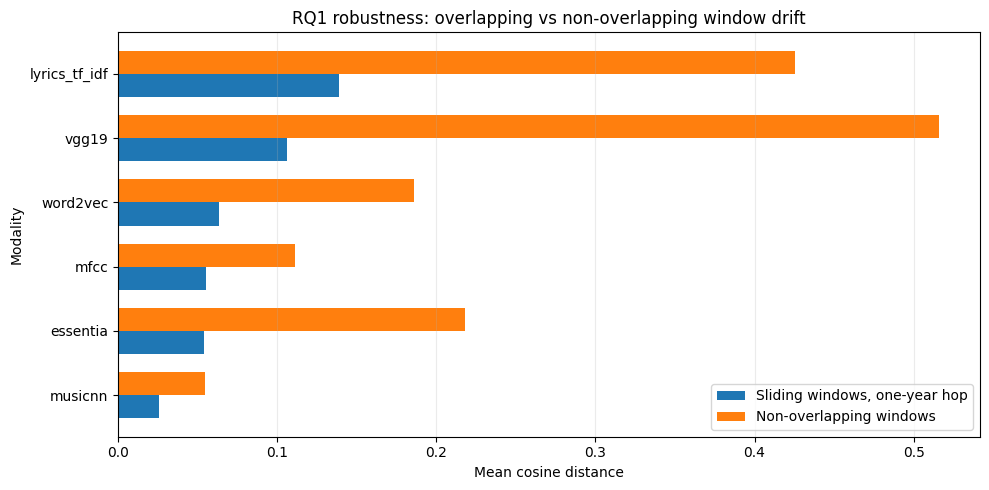

In [29]:
plot_data = window_robustness_comparison.sort_values(
    "overlapping_mean_cosine_distance",
    ascending=True,
)

y = np.arange(len(plot_data))
bar_height = 0.36

plt.figure(figsize=(10, 5))

plt.barh(
    y - bar_height / 2,
    plot_data["overlapping_mean_cosine_distance"],
    height=bar_height,
    label="Sliding windows, one-year hop",
)

plt.barh(
    y + bar_height / 2,
    plot_data["non_overlapping_mean_cosine_distance"],
    height=bar_height,
    label="Non-overlapping windows",
)

plt.yticks(y, plot_data["modality"])
plt.xlabel("Mean cosine distance")
plt.ylabel("Modality")
plt.title("RQ1 robustness: overlapping vs non-overlapping window drift")
plt.legend()
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()

output_path = PLOTS_DIR / "rq1_overlapping_vs_non_overlapping_drift.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

## Bootstrap Confidence Intervals For Mean Modality Drift

This section estimates uncertainty in mean modality drift by resampling drift observations within each modality. The bootstrap intervals are descriptive and do not remove temporal dependence, but they provide a first check of whether modality-level differences are stable.

In [30]:
def bootstrap_mean_ci(
    values: pd.Series,
    n_bootstrap: int = 2000,
    confidence: float = 0.95,
    random_seed: int = 42,
) -> dict[str, float]:
    values = values.dropna().to_numpy(dtype=float)
    rng = np.random.default_rng(random_seed)

    if len(values) == 0:
        return {
            "mean": np.nan,
            "ci_lower": np.nan,
            "ci_upper": np.nan,
        }

    bootstrap_means = np.empty(n_bootstrap)

    for idx in range(n_bootstrap):
        sample = rng.choice(values, size=len(values), replace=True)
        bootstrap_means[idx] = sample.mean()

    alpha = 1 - confidence

    return {
        "mean": values.mean(),
        "ci_lower": np.quantile(bootstrap_means, alpha / 2),
        "ci_upper": np.quantile(bootstrap_means, 1 - alpha / 2),
    }


def bootstrap_modality_summary(
    drift_data: pd.DataFrame,
    label: str,
    random_seed: int = 42,
) -> pd.DataFrame:
    genre_level_data = (
        drift_data
        .groupby(["modality", "genre"], as_index=False)
        .agg(
            genre_mean_cosine_distance=("cosine_distance", "mean"),
            n_transitions=("cosine_distance", "size"),
        )
    )

    rows = []

    for idx, (modality, modality_data) in enumerate(genre_level_data.groupby("modality")):
        ci = bootstrap_mean_ci(
            modality_data["genre_mean_cosine_distance"],
            n_bootstrap=n_bootstrap,
            random_seed=random_seed + idx,
        )
        rows.append({
            "analysis": label,
            "modality": modality,
            "mean_cosine_distance": ci["mean"],
            "ci_lower": ci["ci_lower"],
            "ci_upper": ci["ci_upper"],
            "n_transitions": modality_data["n_transitions"].sum(),
            "n_genres": modality_data["genre"].nunique(),
        })

    return pd.DataFrame(rows)

In [31]:
bootstrap_overlapping = bootstrap_modality_summary(
    drift_wpz_neighbors,
    label="overlapping",
    random_seed=random_seed,
)

bootstrap_non_overlapping = bootstrap_modality_summary(
    non_overlapping_drift,
    label="non_overlapping",
    random_seed=random_seed + 1000,
)

bootstrap_summary = pd.concat(
    [bootstrap_overlapping, bootstrap_non_overlapping],
    ignore_index=True,
)

bootstrap_summary.to_csv(
    DRIFT_DIR / "rq1_bootstrap_modality_drift_summary.csv",
    index=False,
)

bootstrap_summary.sort_values(["analysis", "mean_cosine_distance"], ascending=[True, False])

,analysis,modality,mean_cosine_distance,ci_lower,ci_upper,n_transitions,n_genres
10,non_overlapping,vgg19,0.515918,0.473590,0.558924,382,50
7,non_overlapping,lyrics_tf_idf,0.425376,0.389717,0.462692,402,50
6,non_overlapping,essentia,0.217768,0.189358,0.246298,402,50
11,non_overlapping,word2vec,0.185899,0.159915,0.211336,402,50
8,non_overlapping,mfcc,0.111237,0.095885,0.128403,402,50
9,non_overlapping,musicnn,0.054685,0.046737,0.063678,402,50
1,overlapping,lyrics_tf_idf,0.138907,0.128303,0.148782,2126,50
4,overlapping,vgg19,0.106083,0.096780,0.114915,2040,50
5,overlapping,word2vec,0.063449,0.054122,0.072213,2126,50
2,overlapping,mfcc,0.055587,0.047050,0.064770,2126,50


/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_robustness/rq1_bootstrap_ci_non_overlapping.png


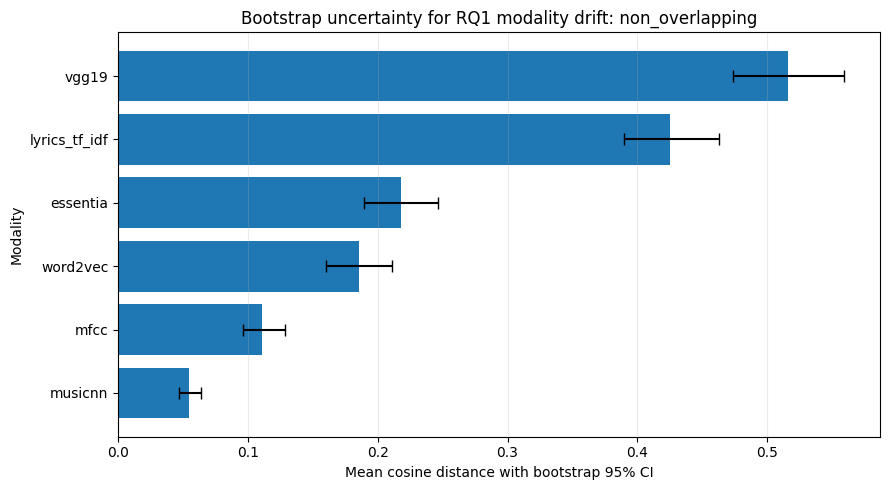

/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_robustness/rq1_bootstrap_ci_overlapping.png


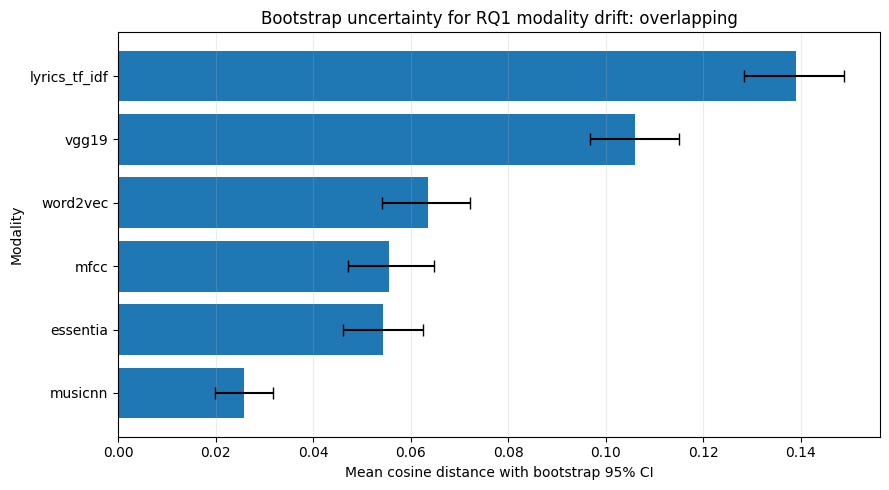

In [32]:
for analysis_label, analysis_data in bootstrap_summary.groupby("analysis"):
    analysis_data = analysis_data.sort_values("mean_cosine_distance", ascending=True)

    plt.figure(figsize=(9, 5))

    lower_error = (
        analysis_data["mean_cosine_distance"]
        - analysis_data["ci_lower"]
    )
    upper_error = (
        analysis_data["ci_upper"]
        - analysis_data["mean_cosine_distance"]
    )

    plt.barh(
        analysis_data["modality"],
        analysis_data["mean_cosine_distance"],
        xerr=[lower_error, upper_error],
        capsize=4,
    )

    plt.xlabel("Mean cosine distance with bootstrap 95% CI")
    plt.ylabel("Modality")
    plt.title(f"Bootstrap uncertainty for RQ1 modality drift: {analysis_label}")
    plt.grid(axis="x", alpha=0.25)
    plt.tight_layout()

    output_path = PLOTS_DIR / f"rq1_bootstrap_ci_{analysis_label}.png"
    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    print(output_path)

    plt.show()

NEW : This cell starts the non-overlapping inferential statistics section and clarifies why these tests are separated from the descriptive overlapping-window analysis.

## Non-Overlapping Inferential Tests

The main RQ1 notebook uses five-year sliding windows with a one-year hop for descriptive trajectories. These windows share most of their tracks, so adjacent estimates are not independent. The following cells therefore use the non-overlapping five-year windows calculated above for inferential checks. This keeps the descriptive analysis and the statistical robustness analysis conceptually separate.


NEW : This cell tests whether modality-level drift distributions differ when only non-overlapping windows are used.


In [33]:
# Kruskal-Wallis test across modalities using non-overlapping windows.
# This is a non-parametric omnibus test: it checks whether at least one
# modality has a different drift distribution from the others.

try:
    from scipy.stats import kruskal

    modality_values = [
        data["genre_mean_cosine_distance"].dropna().to_numpy()
        for _, data in non_overlapping_genre_level.groupby("modality")
    ]

    statistic, p_value = kruskal(*modality_values)

    non_overlapping_omnibus_test = pd.DataFrame({
        "test": ["Kruskal-Wallis"],
        "distance": ["cosine"],
        "analysis": ["non_overlapping"],
        "statistic": [statistic],
        "p_value": [p_value],
        "n_modalities": [non_overlapping_drift["modality"].nunique()],
        "n_transitions": [len(non_overlapping_drift)],
        "note": [
            "Tests whether non-overlapping drift distributions differ across modalities."
        ],
    })

except ImportError:
    non_overlapping_omnibus_test = pd.DataFrame({
        "test": ["Kruskal-Wallis"],
        "distance": ["cosine"],
        "analysis": ["non_overlapping"],
        "statistic": [pd.NA],
        "p_value": [pd.NA],
        "n_modalities": [non_overlapping_drift["modality"].nunique()],
        "n_transitions": [len(non_overlapping_drift)],
        "note": ["scipy is not installed, so the omnibus test was skipped."],
    })

non_overlapping_omnibus_test.to_csv(
    DRIFT_DIR / "rq1_non_overlapping_omnibus_test.csv",
    index=False,
)

non_overlapping_omnibus_test


,test,distance,analysis,statistic,p_value,n_modalities,n_transitions,note
0,Kruskal-Wallis,cosine,non_overlapping,220.810812,9.960421e-46,6,2392,Tests whether non-overlapping drift distributi...


NEW : This cell defines pairwise permutation tests between modalities using non-overlapping windows.


In [34]:
# Pairwise permutation tests compare mean cosine drift between modalities.
# The tests use non-overlapping windows to reduce temporal dependence.
# P-values are adjusted with Benjamini-Hochberg FDR correction.

from itertools import combinations

n_permutations = 10_000
random_seed = 42


def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    n_values = len(p_values)
    order = np.argsort(p_values)
    ranked_p_values = p_values[order]

    adjusted_ranked = ranked_p_values * n_values / np.arange(1, n_values + 1)
    adjusted_ranked = np.minimum.accumulate(adjusted_ranked[::-1])[::-1]
    adjusted_ranked = np.clip(adjusted_ranked, 0, 1)

    adjusted = np.empty(n_values)
    adjusted[order] = adjusted_ranked
    return adjusted


def permutation_test_mean_difference(
    values_a,
    values_b,
    n_permutations=10_000,
    random_seed=42,
):
    values_a = np.asarray(pd.Series(values_a).dropna(), dtype=float)
    values_b = np.asarray(pd.Series(values_b).dropna(), dtype=float)

    observed_difference = values_a.mean() - values_b.mean()
    pooled = np.concatenate([values_a, values_b])
    n_a = len(values_a)

    rng = np.random.default_rng(random_seed)
    n_extreme = 0

    for _ in range(n_permutations):
        permuted = rng.permutation(pooled)
        permuted_difference = (
            permuted[:n_a].mean()
            - permuted[n_a:].mean()
        )

        if abs(permuted_difference) >= abs(observed_difference):
            n_extreme += 1

    p_value = (n_extreme + 1) / (n_permutations + 1)
    return observed_difference, p_value


pairwise_rows = []
modalities_for_tests = sorted(non_overlapping_genre_level["modality"].unique())

for idx, (modality_a, modality_b) in enumerate(
    combinations(modalities_for_tests, 2),
    start=1,
):
    values_a = non_overlapping_genre_level.loc[
        non_overlapping_genre_level["modality"] == modality_a,
        "genre_mean_cosine_distance",
    ]

    values_b = non_overlapping_genre_level.loc[
        non_overlapping_genre_level["modality"] == modality_b,
        "genre_mean_cosine_distance",
    ]

    observed_difference, p_value = permutation_test_mean_difference(
        values_a=values_a,
        values_b=values_b,
        n_permutations=n_permutations,
        random_seed=random_seed + idx,
    )

    pairwise_rows.append({
        "modality_a": modality_a,
        "modality_b": modality_b,
        "mean_a": values_a.mean(),
        "mean_b": values_b.mean(),
        "mean_difference_a_minus_b": observed_difference,
        "p_value": p_value,
        "n_a": values_a.notna().sum(),
        "n_b": values_b.notna().sum(),
    })

pairwise_permutation_tests = pd.DataFrame(pairwise_rows)
pairwise_permutation_tests["p_value_fdr_bh"] = benjamini_hochberg(
    pairwise_permutation_tests["p_value"]
)
pairwise_permutation_tests["significant_fdr_0_05"] = (
    pairwise_permutation_tests["p_value_fdr_bh"] < 0.05
)

pairwise_permutation_tests = pairwise_permutation_tests.sort_values(
    ["p_value_fdr_bh", "p_value"],
).reset_index(drop=True)

pairwise_permutation_tests.to_csv(
    DRIFT_DIR / "rq1_pairwise_permutation_tests_non_overlapping.csv",
    index=False,
)

pairwise_permutation_tests


,modality_a,modality_b,mean_a,mean_b,mean_difference_a_minus_b,p_value,n_a,n_b,p_value_fdr_bh,significant_fdr_0_05
0,essentia,lyrics_tf_idf,0.217768,0.425376,-0.207608,0.000100,50,50,0.000115,True
1,essentia,mfcc,0.217768,0.111237,0.106532,0.000100,50,50,0.000115,True
2,essentia,musicnn,0.217768,0.054685,0.163083,0.000100,50,50,0.000115,True
3,essentia,vgg19,0.217768,0.515918,-0.298150,0.000100,50,50,0.000115,True
4,lyrics_tf_idf,mfcc,0.425376,0.111237,0.314139,0.000100,50,50,0.000115,True
5,lyrics_tf_idf,musicnn,0.425376,0.054685,0.370691,0.000100,50,50,0.000115,True
6,lyrics_tf_idf,word2vec,0.425376,0.185899,0.239477,0.000100,50,50,0.000115,True
7,mfcc,musicnn,0.111237,0.054685,0.056551,0.000100,50,50,0.000115,True
8,mfcc,vgg19,0.111237,0.515918,-0.404681,0.000100,50,50,0.000115,True
9,mfcc,word2vec,0.111237,0.185899,-0.074662,0.000100,50,50,0.000115,True


NEW : This cell visualizes the pairwise permutation-test results as adjusted p-values.


/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_robustness/rq1_pairwise_permutation_tests_non_overlapping.png


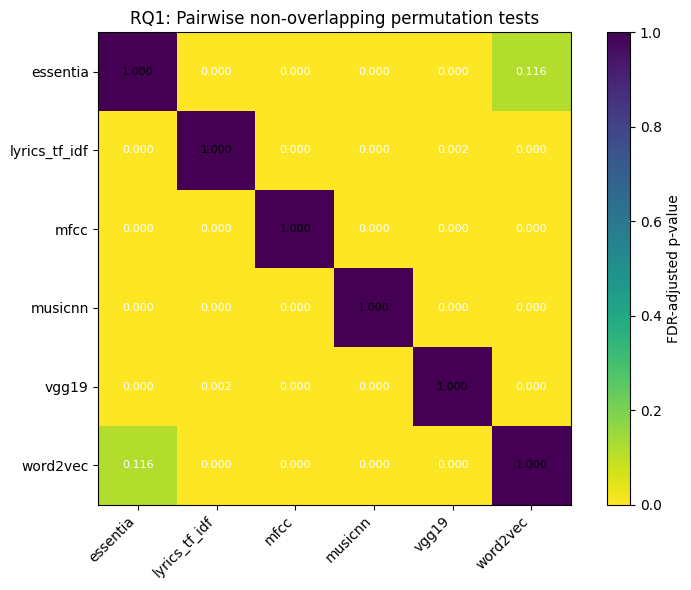

In [35]:
# Heatmap of FDR-adjusted p-values from the pairwise permutation tests.
# Smaller values indicate stronger evidence that two modalities differ in mean drift.

p_value_matrix = pd.DataFrame(
    np.nan,
    index=modalities_for_tests,
    columns=modalities_for_tests,
)

for modality in modalities_for_tests:
    p_value_matrix.loc[modality, modality] = 1.0

for _, row in pairwise_permutation_tests.iterrows():
    modality_a = row["modality_a"]
    modality_b = row["modality_b"]
    adjusted_p = row["p_value_fdr_bh"]

    p_value_matrix.loc[modality_a, modality_b] = adjusted_p
    p_value_matrix.loc[modality_b, modality_a] = adjusted_p

plt.figure(figsize=(8, 6))
plt.imshow(
    p_value_matrix,
    cmap="viridis_r",
    vmin=0,
    vmax=1,
)

plt.xticks(
    range(len(p_value_matrix.columns)),
    p_value_matrix.columns,
    rotation=45,
    ha="right",
)
plt.yticks(
    range(len(p_value_matrix.index)),
    p_value_matrix.index,
)

for i, modality_a in enumerate(p_value_matrix.index):
    for j, modality_b in enumerate(p_value_matrix.columns):
        value = p_value_matrix.loc[modality_a, modality_b]
        if pd.notna(value):
            plt.text(
                j,
                i,
                f"{value:.3f}",
                ha="center",
                va="center",
                color="white" if value < 0.35 else "black",
                fontsize=8,
            )

plt.colorbar(label="FDR-adjusted p-value")
plt.title("RQ1: Pairwise non-overlapping permutation tests")
plt.tight_layout()

output_path = PLOTS_DIR / "rq1_pairwise_permutation_tests_non_overlapping.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()


NEW : This cell creates a compact inferential summary table that combines non-overlapping means, bootstrap intervals, and ranks.


In [36]:
# Compact summary for reporting the non-overlapping robustness result.

non_overlapping_ci = (
    bootstrap_summary[
        bootstrap_summary["analysis"] == "non_overlapping"
    ][
        [
            "modality",
            "ci_lower",
            "ci_upper",
        ]
    ]
    .copy()
)

non_overlapping_inferential_summary = (
    non_overlapping_modality_summary
    .merge(non_overlapping_ci, on="modality", how="left")
    .sort_values("mean_cosine_distance", ascending=False)
    .reset_index(drop=True)
)

non_overlapping_inferential_summary["non_overlapping_rank"] = (
    non_overlapping_inferential_summary.index + 1
)

non_overlapping_inferential_summary = non_overlapping_inferential_summary[
    [
        "non_overlapping_rank",
        "modality",
        "mean_cosine_distance",
        "median_cosine_distance",
        "ci_lower",
        "ci_upper",
        "n_transitions",
        "n_genres",
    ]
]

non_overlapping_inferential_summary.to_csv(
    DRIFT_DIR / "rq1_non_overlapping_inferential_summary.csv",
    index=False,
)

non_overlapping_inferential_summary


,non_overlapping_rank,modality,mean_cosine_distance,median_cosine_distance,ci_lower,ci_upper,n_transitions,n_genres
0,1,vgg19,0.515918,0.526730,0.473590,0.558924,382,50
1,2,lyrics_tf_idf,0.425376,0.444329,0.389717,0.462692,402,50
2,3,essentia,0.217768,0.189549,0.189358,0.246298,402,50
3,4,word2vec,0.185899,0.185997,0.159915,0.211336,402,50
4,5,mfcc,0.111237,0.099000,0.095885,0.128403,402,50
5,6,musicnn,0.054685,0.049769,0.046737,0.063678,402,50


NEW : This cell provides a short LaTeX-ready interpretation template for the added robustness checks.

The non-overlapping-window robustness analysis repeats the RQ1 drift comparison using five-year windows with a five-year hop. This avoids the strongest dependency introduced by the descriptive one-year sliding-window trajectories. The absolute drift values are larger because consecutive non-overlapping windows are farther apart in time. However, the main conclusion remains stable: drift is modality-dependent, with VGG19 and Lyrics TF-IDF showing the strongest non-overlapping drift and MusicNN showing the lowest drift. Bootstrap confidence intervals show clear separation between several modalities. Pairwise permutation tests provide an additional non-parametric check of whether modality-level drift differences remain visible under the non-overlapping-window setup. The null reference compares observed temporally adjacent genre transitions against random cross-window pairings and helps show that observed genre trajectories are more structured than arbitrary temporal pairings.


## Optional Null Reference: Random Cross-Window Genre Pairings

This null reference asks whether the observed same-genre drift is smaller or larger than drift obtained by randomly pairing genre centroids across adjacent non-overlapping windows. For each transition, the observed comparison is:

\[
	ext{genre } g 	ext{ in window } t \quad 	ext{vs.} \quad 	ext{same genre } g 	ext{ in window } t+1.
\]

The null comparison randomly pairs a genre centroid in window \(t\) with a genre centroid from window \(t+1\). This is not a formal hypothesis test yet, but a descriptive reference for whether same-genre continuity is stronger than random cross-window pairing.

In [37]:
def calculate_null_reference_for_modality(
    modality: str,
    representation: str = "wpz",
    n_repetitions: int = 500,
    random_seed: int = 42,
) -> pd.DataFrame:
    rng = np.random.default_rng(random_seed)
    centroids = load_modality_centroids(modality, representation=representation)
    centroids = centroids[
        centroids["window_start"].isin(non_overlapping_window_starts)
    ].copy()

    feature_columns = get_feature_columns(centroids)
    rows = []

    for window_start in non_overlapping_window_starts[:-1]:
        next_window_start = window_start + non_overlapping_hop_size

        current_window = centroids[
            centroids["window_start"] == window_start
        ].copy()
        next_window = centroids[
            centroids["window_start"] == next_window_start
        ].copy()

        if current_window.empty or next_window.empty:
            continue

        current_vectors = current_window[feature_columns].to_numpy(dtype=float)
        next_vectors = next_window[feature_columns].to_numpy(dtype=float)

        for repetition in range(n_repetitions):
            current_idx = rng.integers(0, len(current_vectors))
            next_idx = rng.integers(0, len(next_vectors))

            rows.append({
                "modality": modality,
                "window_start": window_start,
                "next_window_start": next_window_start,
                "repetition": repetition,
                "cosine_distance": cosine_distance(
                    current_vectors[current_idx],
                    next_vectors[next_idx],
                ),
            })

    return pd.DataFrame(rows)

In [38]:
null_reference_parts = []

for idx, modality in enumerate(modalities):
    print("Calculating null reference for", modality)
    modality_null = calculate_null_reference_for_modality(
        modality=modality,
        representation="wpz",
        n_repetitions=n_null_repetitions,
        random_seed=random_seed + idx,
    )
    null_reference_parts.append(modality_null)

null_reference = pd.concat(
    null_reference_parts,
    ignore_index=True,
)

null_reference.to_parquet(
    DRIFT_DIR / "rq1_null_reference_random_cross_window_pairings.parquet",
    index=False,
)

print(null_reference.shape)
null_reference.head()

Calculating null reference for essentia
Calculating null reference for lyrics_tf_idf
Calculating null reference for mfcc
Calculating null reference for musicnn
Calculating null reference for vgg19
Calculating null reference for word2vec
(36000, 5)


,modality,window_start,next_window_start,repetition,cosine_distance
0,essentia,1955,1960,0,0.936503
1,essentia,1955,1960,1,0.401265
2,essentia,1955,1960,2,0.614078
3,essentia,1955,1960,3,0.601806
4,essentia,1955,1960,4,1.273568


In [39]:
observed_non_overlapping_summary = (
    non_overlapping_genre_level
    .groupby("modality", as_index=False)
    .agg(
        observed_mean_cosine_distance=("genre_mean_cosine_distance", "mean"),
        observed_median_cosine_distance=("genre_mean_cosine_distance", "median"),
        observed_n_transitions=("n_transitions", "sum"),
        observed_n_genres=("genre", "nunique"),
    )
)

null_reference_summary = (
    null_reference
    .groupby("modality", as_index=False)
    .agg(
        null_mean_cosine_distance=("cosine_distance", "mean"),
        null_median_cosine_distance=("cosine_distance", "median"),
        null_p05_cosine_distance=("cosine_distance", lambda values: values.quantile(0.05)),
        null_p95_cosine_distance=("cosine_distance", lambda values: values.quantile(0.95)),
        null_n_pairings=("cosine_distance", "size"),
    )
)

null_comparison = observed_non_overlapping_summary.merge(
    null_reference_summary,
    on="modality",
    how="inner",
)

null_comparison["observed_minus_null_mean"] = (
    null_comparison["observed_mean_cosine_distance"]
    - null_comparison["null_mean_cosine_distance"]
)

null_comparison.to_csv(
    DRIFT_DIR / "rq1_null_reference_comparison.csv",
    index=False,
)

null_comparison.sort_values("observed_mean_cosine_distance", ascending=False)

,modality,observed_mean_cosine_distance,observed_median_cosine_distance,observed_n_transitions,observed_n_genres,null_mean_cosine_distance,null_median_cosine_distance,null_p05_cosine_distance,null_p95_cosine_distance,null_n_pairings,observed_minus_null_mean
4,vgg19,0.515918,0.526730,382,50,0.949886,0.946523,0.466328,1.434053,6000,-0.433968
1,lyrics_tf_idf,0.425376,0.444329,402,50,0.640425,0.656810,0.340227,0.880536,6000,-0.215049
0,essentia,0.217768,0.189549,402,50,0.822609,0.814403,0.232002,1.463371,6000,-0.604840
5,word2vec,0.185899,0.185997,402,50,0.614201,0.559933,0.176968,1.233872,6000,-0.428303
2,mfcc,0.111237,0.099000,402,50,0.397488,0.358024,0.102406,0.814262,6000,-0.286252
3,musicnn,0.054685,0.049769,402,50,0.429020,0.385088,0.070664,0.926654,6000,-0.374335


/home/tobias-wollendorfer/student1/master_thesis/multimodal-temporal-music-analysis/plots/RQ1_robustness/rq1_observed_vs_null_reference.png


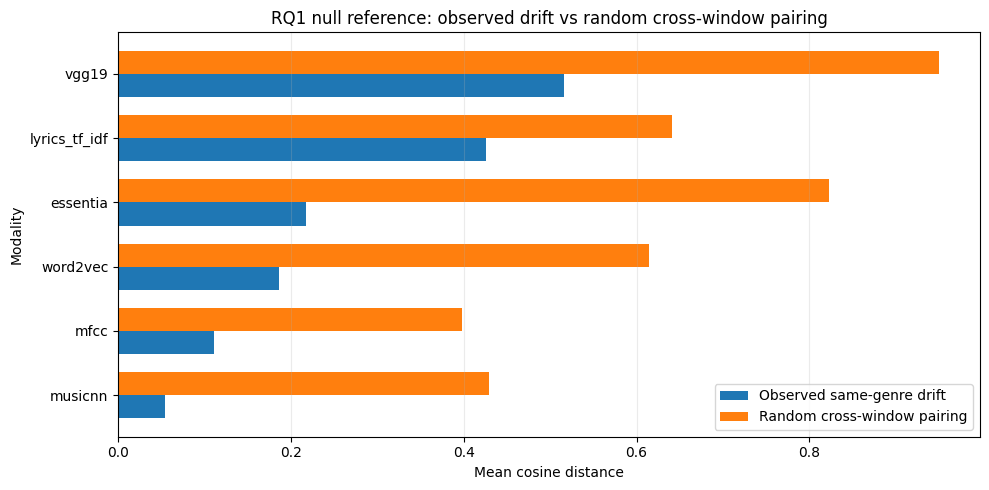

In [40]:
plot_data = null_comparison.sort_values(
    "observed_mean_cosine_distance",
    ascending=True,
)

y = np.arange(len(plot_data))
bar_height = 0.36

plt.figure(figsize=(10, 5))

plt.barh(
    y - bar_height / 2,
    plot_data["observed_mean_cosine_distance"],
    height=bar_height,
    label="Observed same-genre drift",
)

plt.barh(
    y + bar_height / 2,
    plot_data["null_mean_cosine_distance"],
    height=bar_height,
    label="Random cross-window pairing",
)

plt.yticks(y, plot_data["modality"])
plt.xlabel("Mean cosine distance")
plt.ylabel("Modality")
plt.title("RQ1 null reference: observed drift vs random cross-window pairing")
plt.legend()
plt.grid(axis="x", alpha=0.25)
plt.tight_layout()

output_path = PLOTS_DIR / "rq1_observed_vs_null_reference.png"
plt.savefig(output_path, dpi=300, bbox_inches="tight")
print(output_path)

plt.show()

## Robustness Summary Template

Use this cell after running the notebook to write a short summary. Focus on whether the modality ranking from the main RQ1 analysis remains stable.

In [41]:
print("Overlapping vs non-overlapping ranking:")
display(window_robustness_comparison.sort_values("overlapping_rank"))

print("Bootstrap confidence intervals:")
display(bootstrap_summary.sort_values(["analysis", "mean_cosine_distance"], ascending=[True, False]))

print("Observed vs null reference:")
display(null_comparison.sort_values("observed_mean_cosine_distance", ascending=False))

Overlapping vs non-overlapping ranking:


,modality,overlapping_mean_cosine_distance,overlapping_n_transitions,overlapping_n_genres,non_overlapping_mean_cosine_distance,non_overlapping_n_transitions,non_overlapping_n_genres,overlapping_rank,non_overlapping_rank,rank_change
1,lyrics_tf_idf,0.138907,2126,50,0.425376,402,50,1,2,1
4,vgg19,0.106083,2040,50,0.515918,382,50,2,1,-1
5,word2vec,0.063449,2126,50,0.185899,402,50,3,4,1
2,mfcc,0.055587,2126,50,0.111237,402,50,4,5,1
0,essentia,0.054251,2126,50,0.217768,402,50,5,3,-2
3,musicnn,0.025754,2126,50,0.054685,402,50,6,6,0


Bootstrap confidence intervals:


,analysis,modality,mean_cosine_distance,ci_lower,ci_upper,n_transitions,n_genres
10,non_overlapping,vgg19,0.515918,0.473590,0.558924,382,50
7,non_overlapping,lyrics_tf_idf,0.425376,0.389717,0.462692,402,50
6,non_overlapping,essentia,0.217768,0.189358,0.246298,402,50
11,non_overlapping,word2vec,0.185899,0.159915,0.211336,402,50
8,non_overlapping,mfcc,0.111237,0.095885,0.128403,402,50
9,non_overlapping,musicnn,0.054685,0.046737,0.063678,402,50
1,overlapping,lyrics_tf_idf,0.138907,0.128303,0.148782,2126,50
4,overlapping,vgg19,0.106083,0.096780,0.114915,2040,50
5,overlapping,word2vec,0.063449,0.054122,0.072213,2126,50
2,overlapping,mfcc,0.055587,0.047050,0.064770,2126,50


Observed vs null reference:


,modality,observed_mean_cosine_distance,observed_median_cosine_distance,observed_n_transitions,observed_n_genres,null_mean_cosine_distance,null_median_cosine_distance,null_p05_cosine_distance,null_p95_cosine_distance,null_n_pairings,observed_minus_null_mean
4,vgg19,0.515918,0.526730,382,50,0.949886,0.946523,0.466328,1.434053,6000,-0.433968
1,lyrics_tf_idf,0.425376,0.444329,402,50,0.640425,0.656810,0.340227,0.880536,6000,-0.215049
0,essentia,0.217768,0.189549,402,50,0.822609,0.814403,0.232002,1.463371,6000,-0.604840
5,word2vec,0.185899,0.185997,402,50,0.614201,0.559933,0.176968,1.233872,6000,-0.428303
2,mfcc,0.111237,0.099000,402,50,0.397488,0.358024,0.102406,0.814262,6000,-0.286252
3,musicnn,0.054685,0.049769,402,50,0.429020,0.385088,0.070664,0.926654,6000,-0.374335
